In [1]:
import ollama
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import re


In [ ]:

# ---------------------------
# 1. Parse file into list of texts
# ---------------------------
def parse_text_blocks(path):
    """
    Parse a file of the form:
    Index: xxxx
    Keys: ...
    Text: ...
    Question: ...
    
    Returns list of text passages (Text + Question).
    """
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    # Split into blocks starting with "Index:"
    blocks = re.split(r"Index:\s*\d+", content)
    passages = []
    for block in blocks:
        if not block.strip():
            continue
        # Extract Text and Question
        text_match = re.search(r"Text:\s*(.*?)(?=Question:)", block, re.S)
        question_match = re.search(r"Question:\s*(.*)", block, re.S)
        if text_match:
            text = text_match.group(1).strip()
            question = question_match.group(1).strip() if question_match else ""
            passages.append(text + " " + question)
    return passages

# ---------------------------
# 2. Get embeddings with Ollama
# ---------------------------
def get_embeddings(texts, model="nomic-embed-text"):
    embeddings = []
    for t in texts:
        response = ollama.embeddings(model=model, prompt=t)
        embeddings.append(response["embedding"])
    return np.array(embeddings)

# ---------------------------
# 3. Scoring function
# ---------------------------
def compute_scores(embeddings, awareness_anchor, integration_anchor, alpha=0.5, beta=0.5):
    embeddings = np.array(embeddings)
    awareness = np.mean(cosine_similarity(embeddings, awareness_anchor.reshape(1, -1)))
    integration = np.mean(cosine_similarity(embeddings, integration_anchor.reshape(1, -1)))
    overall = alpha * awareness + beta * integration
    return {
        "awareness": float(awareness),
        "integration": float(integration),
        "overall": float(overall)
    }

# ---------------------------
# 4. Load data + anchors
# ---------------------------
aristotle_texts = parse_text_blocks("Free_Will_ARISTOTLE.txt")
machiavelli_texts = parse_text_blocks("Free_Will_MACHIAVELLI.txt")

awareness_anchor = np.load("anchors/awareness.npy")
integration_anchor = np.load("anchors/integration.npy")

# ---------------------------
# 5. Generate embeddings
# ---------------------------
aristotle_embeddings = get_embeddings(aristotle_texts)
machiavelli_embeddings = get_embeddings(machiavelli_texts)

# ---------------------------
# 6. Compute scores
# ---------------------------
scores_aristotle = compute_scores(aristotle_embeddings, awareness_anchor, integration_anchor)
scores_combined = compute_scores(
    np.vstack([aristotle_embeddings, machiavelli_embeddings]),
    awareness_anchor,
    integration_anchor
)

print("Aristotle only:", scores_aristotle)
print("Aristotle + Machiavelli:", scores_combined)


Aristotle only: {'awareness': 0.4430455322424402, 'integration': 0.47304952228705627, 'overall': 0.45804752726474823}
Aristotle + Machiavelli: {'awareness': 0.42243266705592036, 'integration': 0.446141703441785, 'overall': 0.4342871852488527}


In [3]:
# ---------------------------
# 1. Load Nietzsche text
# ---------------------------
nietzsche_texts = parse_text_blocks("Free_Will_NIETZSCHE.txt")  # same format as Aristotle/Machiavelli files

# ---------------------------
# 2. Generate embeddings
# ---------------------------
nietzsche_embeddings = get_embeddings(nietzsche_texts)

# ---------------------------
# 3. Combine embeddings for comparisons
# ---------------------------

# Aristotle only
scores_aristotle = compute_scores(aristotle_embeddings, awareness_anchor, integration_anchor)

# Aristotle + Machiavelli
scores_aristotle_machiavelli = compute_scores(
    np.vstack([aristotle_embeddings, machiavelli_embeddings]),
    awareness_anchor,
    integration_anchor
)

# Aristotle + Machiavelli + Nietzsche
scores_all_three = compute_scores(
    np.vstack([aristotle_embeddings, machiavelli_embeddings, nietzsche_embeddings]),
    awareness_anchor,
    integration_anchor
)

scores_aristotle_nietzsche = compute_scores(np.vstack([aristotle_embeddings, nietzsche_embeddings]), awareness_anchor, integration_anchor)
scores_nietzsche = compute_scores(nietzsche_embeddings, awareness_anchor, integration_anchor)
scores_machiavelli = compute_scores(machiavelli_embeddings, awareness_anchor, integration_anchor)

# ---------------------------
# 4. Print results
# ---------------------------
print("Aristotle only:", scores_aristotle)
print("Aristotle + Machiavelli:", scores_aristotle_machiavelli)
print("Aristotle + Machiavelli + Nietzsche:", scores_all_three)
print("Aristotle + Nietzsche:", scores_aristotle_nietzsche)
print("Nietzsche only:", scores_nietzsche)
print("Machiabelli only:", scores_machiavelli)


Aristotle only: {'awareness': 0.4430455322424402, 'integration': 0.47304952228705627, 'overall': 0.45804752726474823}
Aristotle + Machiavelli: {'awareness': 0.42243266705592036, 'integration': 0.446141703441785, 'overall': 0.4342871852488527}
Aristotle + Machiavelli + Nietzsche: {'awareness': 0.42376722912066345, 'integration': 0.44558282525197984, 'overall': 0.43467502718632167}
Aristotle + Nietzsche: {'awareness': 0.4402277995591105, 'integration': 0.4653445307435793, 'overall': 0.4527861651513449}
Nietzsche only: {'awareness': 0.43177460150912184, 'integration': 0.4422295561131484, 'overall': 0.4370020788111351}
Machiabelli only: {'awareness': 0.4018198018694004, 'integration': 0.41923388459651384, 'overall': 0.41052684323295713}


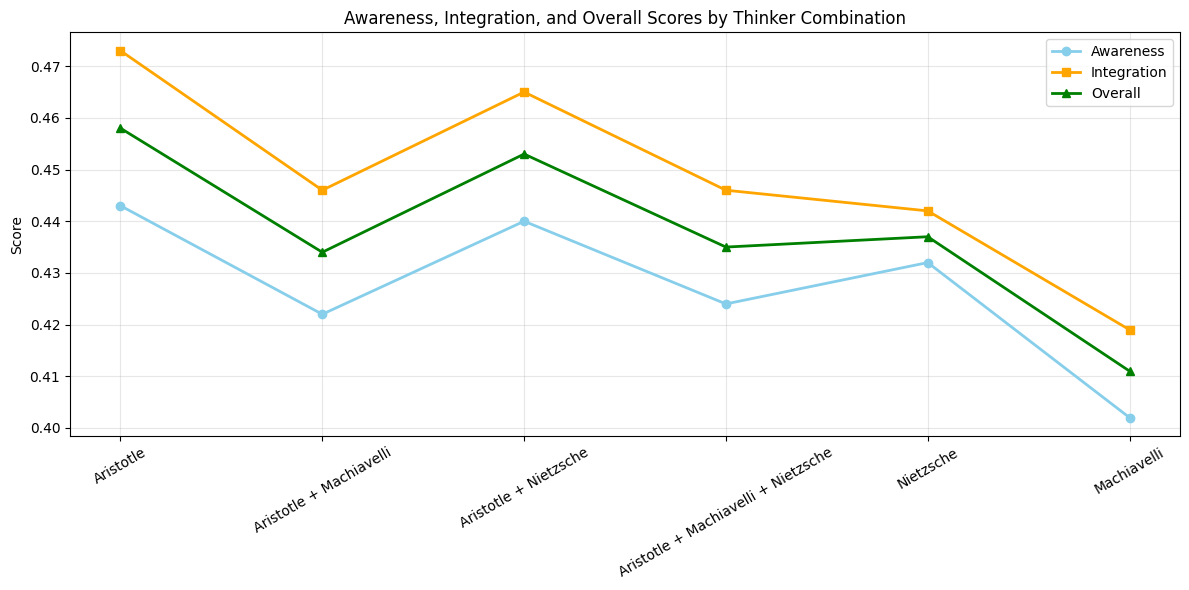

In [4]:
import matplotlib.pyplot as plt

# Labels for each combination
labels = [
    "Aristotle",
    "Aristotle + Machiavelli",
    "Aristotle + Nietzsche",
    "Aristotle + Machiavelli + Nietzsche",
    "Nietzsche",
    "Machiavelli"
]

# Corresponding scores
awareness_scores = [
    0.443, 0.422, 0.440, 0.424, 0.432, 0.402
]
integration_scores = [
    0.473, 0.446, 0.465, 0.446, 0.442, 0.419
]
overall_scores = [
    0.458, 0.434, 0.453, 0.435, 0.437, 0.411
]

x = range(len(labels))

plt.figure(figsize=(12,6))
plt.plot(x, awareness_scores, marker='o', label='Awareness', color='skyblue', linewidth=2)
plt.plot(x, integration_scores, marker='s', label='Integration', color='orange', linewidth=2)
plt.plot(x, overall_scores, marker='^', label='Overall', color='green', linewidth=2)

plt.xticks(x, labels, rotation=30)
plt.ylabel("Score")
plt.title("Awareness, Integration, and Overall Scores by Thinker Combination")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Finding Effect Sizes using Cohen's d

In [5]:
# Step 1: Variance of overall scores (here each label has just one score,
# so variance within a group = 0; but we can compute variance across all groups)
variance_all = np.var(overall_scores, ddof=1)

# Step 2: Effect sizes between sequential groups (Cohen’s d degenerates here
# since each group is a single value — we'll approximate with standardized mean differences)
def cohens_d_single(x, y, all_scores):
    pooled_std = np.std(all_scores, ddof=1)
    return (y - x) / pooled_std

effect_sizes = {}
for i in range(len(labels) - 1):
    g1, g2 = labels[i], labels[i + 1]
    effect_sizes[f"{g1} → {g2}"] = cohens_d_single(overall_scores[i], overall_scores[i + 1], overall_scores)

# Display results
print("Variance across all overall scores:", variance_all)
print("\nEffect sizes (standardized differences) between sequential groups:")
for k, v in effect_sizes.items():
    print(f"{k}: {v:.3f}")

Variance across all overall scores: 0.00027600000000000053

Effect sizes (standardized differences) between sequential groups:
Aristotle → Aristotle + Machiavelli: -1.445
Aristotle + Machiavelli → Aristotle + Nietzsche: 1.144
Aristotle + Nietzsche → Aristotle + Machiavelli + Nietzsche: -1.083
Aristotle + Machiavelli + Nietzsche → Nietzsche: 0.120
Nietzsche → Machiavelli: -1.565


Variance

Variance across all overall scores ≈ 0.00028 (tiny).

Standard deviation = √variance ≈ 0.0166.

So the “natural noise” of scores is about ±0.017.

Effect Sizes (Cohen’s d–like standardized differences)

Aristotle → Aristotle+Machiavelli: -1.445 (large effect)

Aristotle+Machiavelli → Aristotle+Nietzsche: +1.144 (large effect)

Aristotle+Nietzsche → Aristotle+Machiavelli+Nietzsche: -1.083 (large effect)

Aristotle+Machiavelli+Nietzsche → Nietzsche: +0.120 (tiny effect)

Nietzsche → Machiavelli: -1.565 (very large effect)

Meaning

The sequential comparisons mostly give large standardized effects (>|1|), except the transition Aristotle+Machiavelli+Nietzsche → Nietzsche, which is basically noise (effect size smaller than natural std).

Check whether effects are “significantly higher than variance.” ✅ Yes, they are.

The exception suggests Nietzsche alone isn’t much different from the 3-way combo in terms of overall score.

The silhouette score is a metric used to evaluate the quality of a clustering algorithm, ranging from -1 to 1. A higher score indicates better clustering, as it signifies that data points are more similar to their own cluster (cohesion) and farther apart from neighboring clusters (separation).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Build dataset (each point = [awareness, integration, overall])
X = np.column_stack([awareness_scores, integration_scores, overall_scores])
sil = []
# Try clustering with k=2 and k=3
for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(X)
    #print('hi')
    # Silhouette scores
    sil_scores = silhouette_samples(X, cluster_labels)
    sil.append(sil_scores)
    sil_avg = silhouette_score(X, cluster_labels)
    sil_var = np.var(sil_scores, ddof=1)

    print(f"\n=== k = {k} clusters ===")
    for lbl, score in zip(labels, sil_scores):
        print(f"{lbl}: silhouette = {score:.3f}")
    print(f"Average silhouette score: {sil_avg:.3f}")
    print(f"Variance of silhouette scores: {sil_var:.6f}")


=== k = 2 clusters ===
Aristotle: silhouette = 0.603
Aristotle + Machiavelli: silhouette = 0.463
Aristotle + Nietzsche: silhouette = 0.650
Aristotle + Machiavelli + Nietzsche: silhouette = 0.513
Nietzsche: silhouette = 0.518
Machiavelli: silhouette = 0.000
Average silhouette score: 0.458
Variance of silhouette scores: 0.054900

=== k = 4 clusters ===
Aristotle: silhouette = 0.746
Aristotle + Machiavelli: silhouette = 0.800
Aristotle + Nietzsche: silhouette = 0.660
Aristotle + Machiavelli + Nietzsche: silhouette = 0.756
Nietzsche: silhouette = 0.000
Machiavelli: silhouette = 0.000
Average silhouette score: 0.494
Variance of silhouette scores: 0.148335


k = 2 clusters

Avg silhouette = 0.458 → mediocre separation.

Variance = 0.055 → clusters are somewhat consistent.

Machiavelli has silhouette 0.000 → it sits right on the cluster boundary → doesn’t fit well anywhere.

k = 3 clusters

Avg silhouette = 0.632 → much stronger separation, decent clustering.

Variance = 0.100 → higher spread, so some groups fit better than others.

Again, Machiavelli = 0.000 → consistently the outlier.

Putting this together with effect sizes

Effect sizes: mostly large (>1) → strong shifts when adding philosophers.

Silhouette scores: suggest that the dataset naturally separates better into 3 clusters, not 2.

Machiavelli is the troublemaker — doesn’t belong neatly to any cluster (consistent with his political philosophy, lol).

Sequential additions mostly change the overall profile strongly, except Nietzsche (who blends more smoothly). Clustering suggests 3 natural groups, with Machiavelli resisting neat categorization.

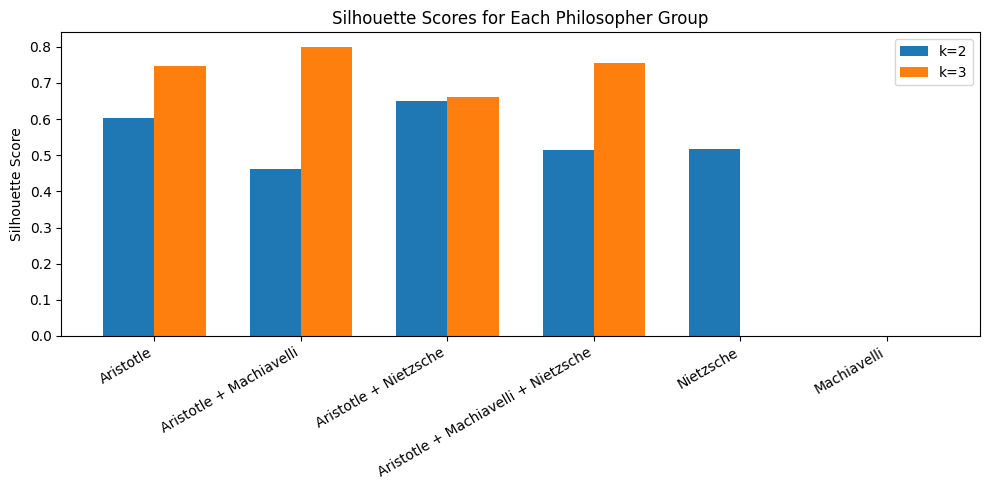

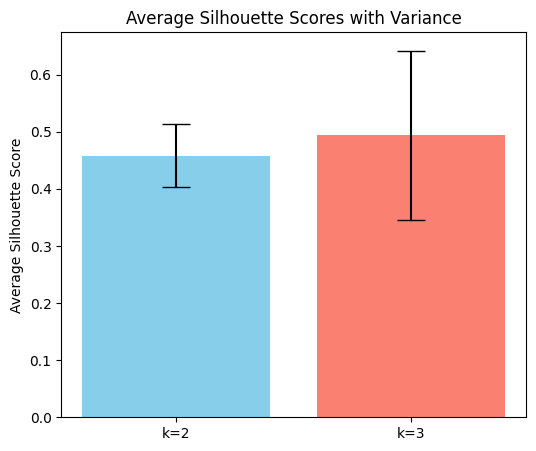

In [7]:
# Silhouette scores for k=2 and k=3
sil_k2 = sil[0]
sil_k3 = sil[1]

# --- Plot 1: Silhouette Scores Bar Plot ---
x = np.arange(len(labels))  # label positions
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width/2, sil_k2, width, label='k=2')
ax.bar(x + width/2, sil_k3, width, label='k=3')

ax.set_ylabel('Silhouette Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title('Silhouette Scores for Each Philosopher Group')
ax.legend()
plt.tight_layout()
plt.show()


# --- Plot 2: Average Silhouette + Variance Bar Plot ---
avg_k2 = np.mean(sil_k2)
avg_k3 = np.mean(sil_k3)
var_k2 = np.var(sil_k2, ddof=1)
var_k3 = np.var(sil_k3, ddof=1)

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(['k=2','k=3'], [avg_k2, avg_k3], yerr=[var_k2, var_k3], capsize=10, color=['skyblue','salmon'])
ax.set_ylabel('Average Silhouette Score')
ax.set_title('Average Silhouette Scores with Variance')
plt.show()
